In [33]:
import numpy as np
import matplotlib.pyplot as plt

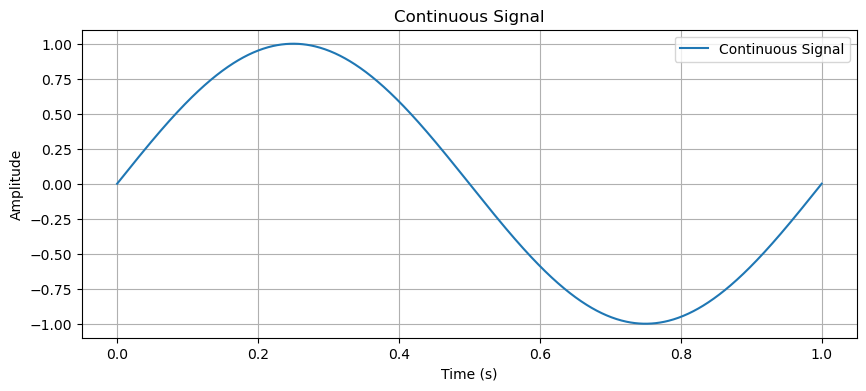

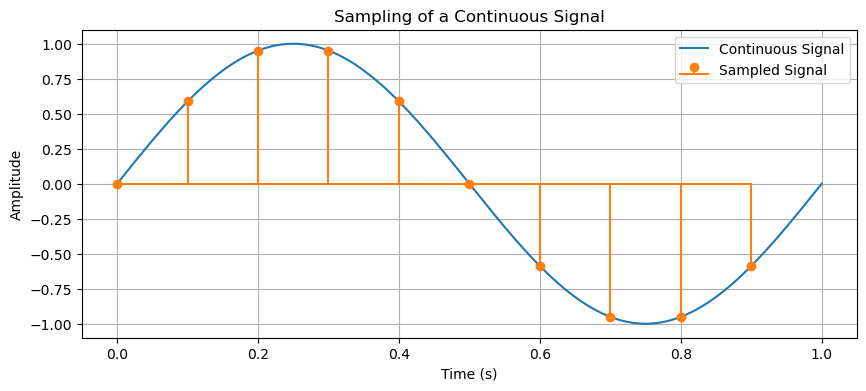

In [34]:
# x is a continuous signal
x = np.linspace(0, 1, 1000)
# y is the sampled signal
y = np.sin(2 * np.pi * 1 * x)  # 1 Hz sine wave

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Continuous Signal')
plt.title('Continuous Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

# Sampling the signal at 10 Hz
sampling_rate = 10  # Hz
sampled_x = np.arange(0, 1, 1/sampling_rate)
sampled_y = np.sin(2 * np.pi * 1 * sampled_x)

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Continuous Signal')
plt.stem(sampled_x, sampled_y, label='Sampled Signal', linefmt='C1-', markerfmt='C1o', basefmt='C1-')
plt.title('Sampling of a Continuous Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

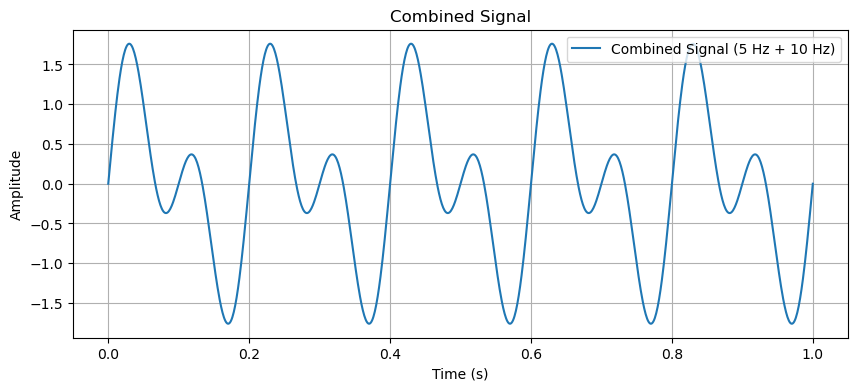

In [44]:
n = np.linspace(0, 1, 1000)
y1 = np.sin(2 * np.pi * 5 * n)  # 5 Hz sine wave
y2 = np.sin(2 * np.pi * 10 * n)  # 10 Hz sine wave
y_combined = y1 + y2
plt.figure(figsize=(10, 4))
plt.plot(n, y_combined, label='Combined Signal (5 Hz + 10 Hz)')
plt.title('Combined Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

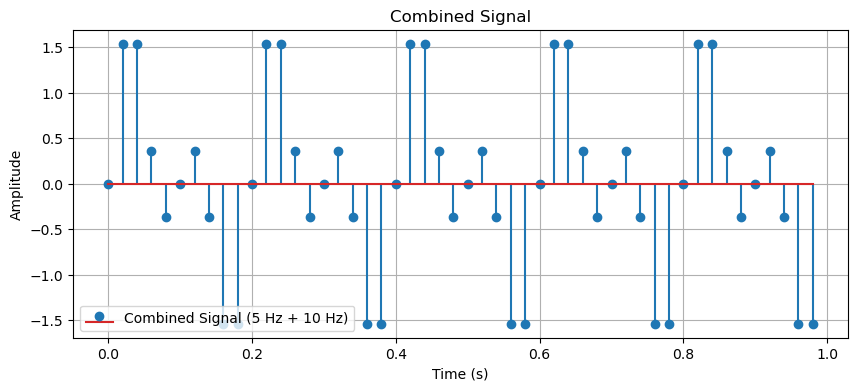

In [46]:
fs = 50  # Sampling frequency
n = np.arange(0, 1, 1/fs)
y1 = np.sin(2 * np.pi * 5 * n)  # 5 Hz sine wave
y2 = np.sin(2 * np.pi * 10 * n)  # 10 Hz sine wave
y_combined = y1 + y2  
plt.figure(figsize=(10, 4))
plt.stem(n, y_combined, label='Combined Signal (5 Hz + 10 Hz)')
plt.title('Combined Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()



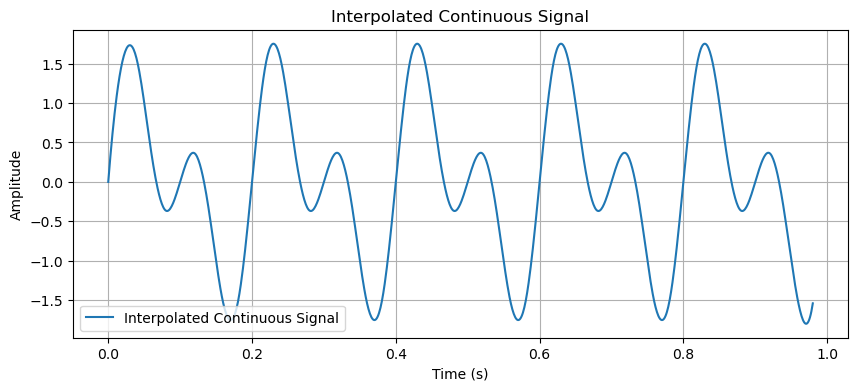

In [49]:
# convert the combined descrete signal to continuous signal
from scipy.interpolate import interp1d
f = interp1d(n, y_combined, kind='cubic')
n_continuous = np.linspace(0, n[-1], 1000)
y_continuous = f(n_continuous)
plt.figure(figsize=(10, 4))
plt.plot(n_continuous, y_continuous, label='Interpolated Continuous Signal')
plt.title('Interpolated Continuous Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()  


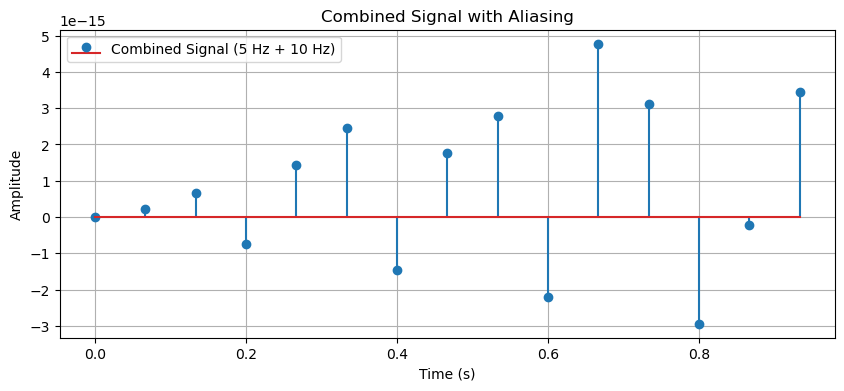

In [52]:
fs = 15 # Sampling frequency
n = np.arange(0, 1, 1/fs)
y1 = np.sin(2 * np.pi * 5 * n)  # 5 Hz sine wave
y2 = np.sin(2 * np.pi * 10 * n)  # 10 Hz sine wave
y_combined = y1 + y2
plt.figure(figsize=(10, 4))
plt.stem(n, y_combined, label='Combined Signal (5 Hz + 10 Hz)')
plt.title('Combined Signal with Aliasing')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

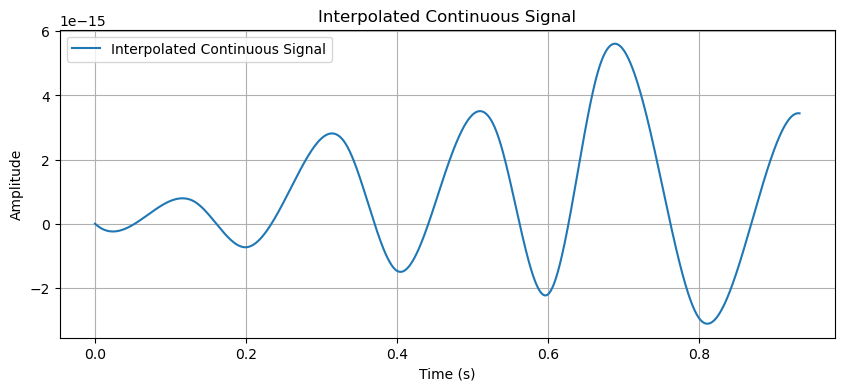

In [53]:
f = interp1d(n, y_combined, kind='cubic')
n_continuous = np.linspace(0, n[-1], 1000)
y_continuous = f(n_continuous)
plt.figure(figsize=(10, 4))
plt.plot(n_continuous, y_continuous, label='Interpolated Continuous Signal')
plt.title('Interpolated Continuous Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()  

DFT AND IDFT

In [87]:
fs = 100
n =  np.arange(0, 1, 1/fs)
y1 = 2 * np.sin(2 * np.pi * 5 * n)  # 5 Hz sine wave
y2 = np.sin(2 * np.pi * 10 * n)  # 10 Hz sine wave
y_combined = y1 + y2


In [88]:
def dft(signal):
    N = len(signal)
    y = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            y[k] += signal[n] * np.exp(-2j * np.pi * k * n / N)

    return y
    return np.array([sum(signal[n] * np.exp(-2j * np.pi * k * n / N) for n in range(N)) for k in range(N)])

In [89]:
fft_result = dft(y_combined)
# fft_result_builtin = np.fft.fft(y_combined)
fft_result_magnitude = np.abs(fft_result)
fft_result_phase = np.angle(fft_result)

frequencies = np.fft.fftfreq(len(y_combined), d=1/fs)


In [90]:
#function for idft
def idft(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)
    return x / N

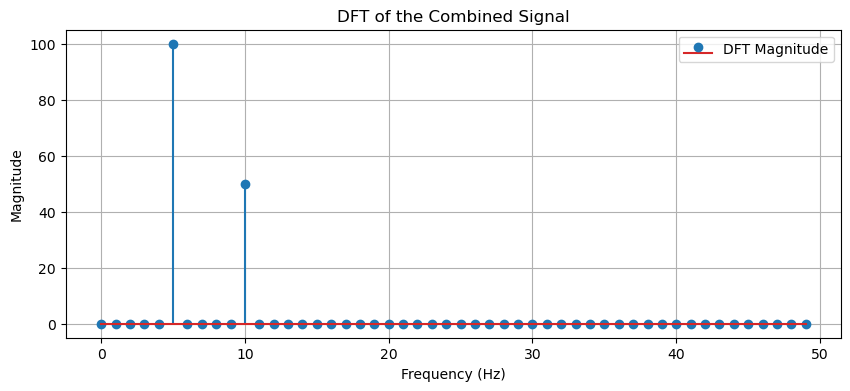

In [91]:
plt.figure(figsize=(10, 4))
plt.stem(frequencies[:len(frequencies)//2], np.abs(fft_result_magnitude)[:len(fft_result_magnitude)//2], label='DFT Magnitude')
plt.title('DFT of the Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.show()


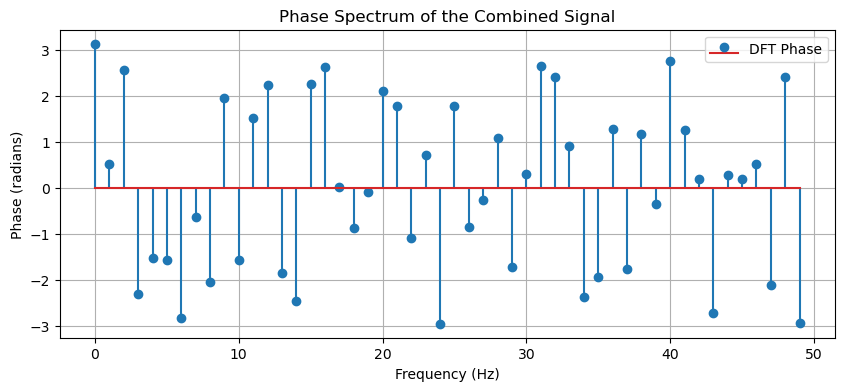

In [92]:
plt.figure(figsize=(10, 4))
plt.stem(frequencies[:len(frequencies)//2], fft_result_phase[:len(fft_result_phase)//2], label='DFT Phase')
plt.title('Phase Spectrum of the Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.grid()
plt.legend()
plt.show()


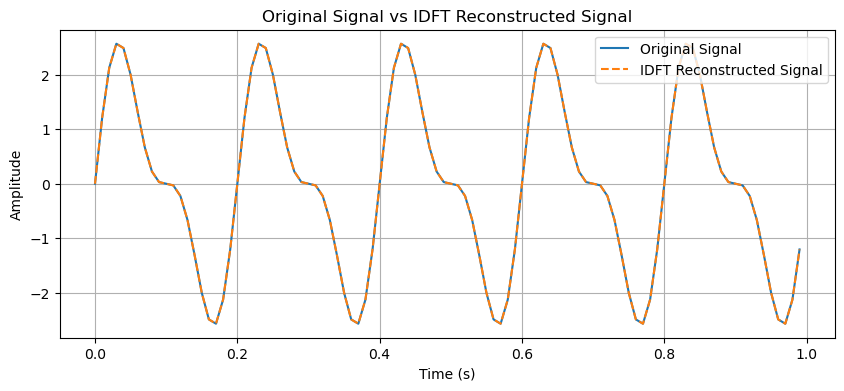

In [93]:
idft_result = idft(fft_result)
plt.figure(figsize=(10, 4))
plt.plot(n, y_combined, label='Original Signal')
plt.plot(n, idft_result.real, label='IDFT Reconstructed Signal', linestyle='--')
plt.title('Original Signal vs IDFT Reconstructed Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()


In [100]:
# n point dft function
def n_point_dft(signal, N):
    y = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(len(signal)):
            y[k] += signal[n] * np.exp(-2j * np.pi * k * n / N)
    return y

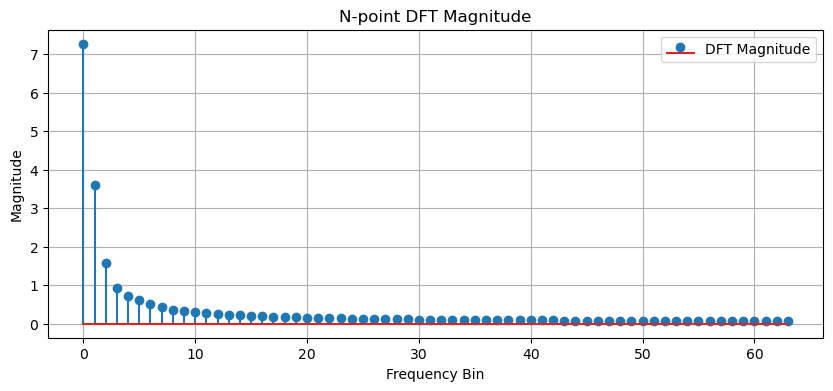

In [108]:
#n point dft
N = 128 # DFT length
# x = np.array([0, 1, 2, 3, 4, 5, 6, 7])  # Example signal (length less than N)
# n = np.arange(N)
n = np.arange(0,1,0.01)
x = np.sin(2 * np.pi * 3 * n / N)  # Example signal (3 Hz sine wave)
X = n_point_dft(x, N)
plt.figure(figsize=(10, 4))
plt.stem(np.arange(N)[:N//2], np.abs(X)[:N//2], label='DFT Magnitude')
plt.title('N-point DFT Magnitude')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.show()
